
[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
diabet_col: 58
lipid_cols: 20
kidney_cols: 354
liver_cols: 95
(58, 4)
(20, 5)
(354, 5)
(95, 5)
fbs
0    40
1    18
Name: count, dtype: int64
tg
0    17
1     3
Name: count, dtype: int64
chol
0    19
1     1
Name: count, dtype: int64
cr
0    300
1     54
Name: count, dtype: int64
bun
0    295
1     59
Name: count, dtype: int64
sgot
0    68
1    27
Name: count, dtype: int64
sgpt
0    71
1    24
Name: count, dtype: int64
Accuracy_creatinine: 0.6056338028169014
[[40 26]
 [ 2  3]]
              precision    recall  f1-score   support

           0       0.95      0.61      0.74        66
           1       0.10      0.60      0.18         5

    accuracy                           0.61        71
   macro avg       0.53      0.60      0.46        71
weighted avg       0.89      0.61      0.70        71



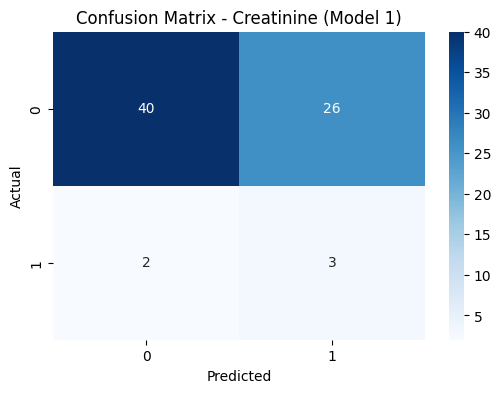

Accuracy_creatinine_with_smote: 0.6056338028169014
[[45 21]
 [ 3  2]]
              precision    recall  f1-score   support

           0       0.95      0.61      0.74        66
           1       0.10      0.60      0.18         5

    accuracy                           0.61        71
   macro avg       0.53      0.60      0.46        71
weighted avg       0.89      0.61      0.70        71



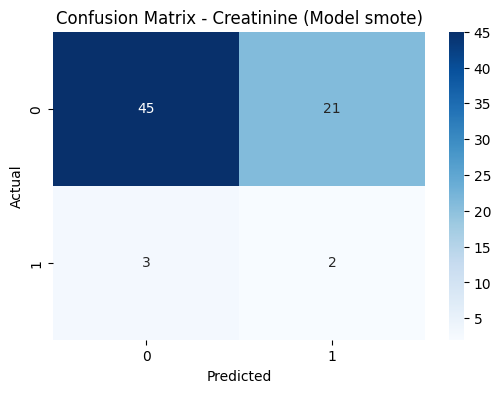

Accuracy_creatinine_2: 0.6197183098591549
[[42 24]
 [ 3  2]]
              precision    recall  f1-score   support

           0       0.93      0.64      0.76        66
           1       0.08      0.40      0.13         5

    accuracy                           0.62        71
   macro avg       0.51      0.52      0.44        71
weighted avg       0.87      0.62      0.71        71

/root/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


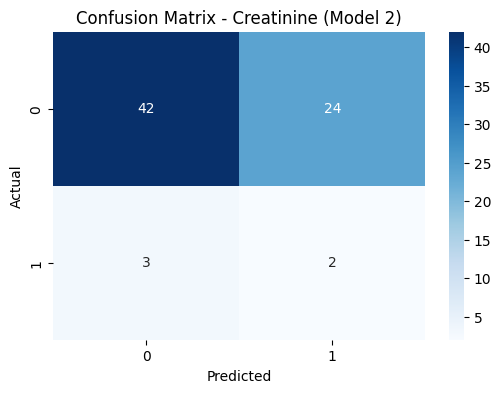

Accuracy_bun: 0.676056338028169
[[46 20]
 [ 3  2]]
              precision    recall  f1-score   support

           0       0.94      0.70      0.80        66
           1       0.09      0.40      0.15         5

    accuracy                           0.68        71
   macro avg       0.51      0.55      0.47        71
weighted avg       0.88      0.68      0.75        71



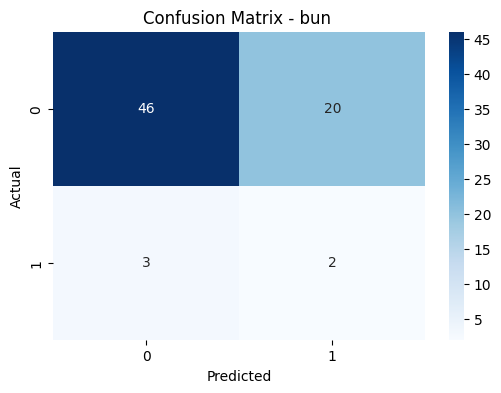

liver
0    62
1    33
Name: count, dtype: int64
Accuracy_liver: 0.6842105263157895
[[6 3]
 [3 7]]
              precision    recall  f1-score   support

           0       0.67      0.67      0.67         9
           1       0.70      0.70      0.70        10

    accuracy                           0.68        19
   macro avg       0.68      0.68      0.68        19
weighted avg       0.68      0.68      0.68        19



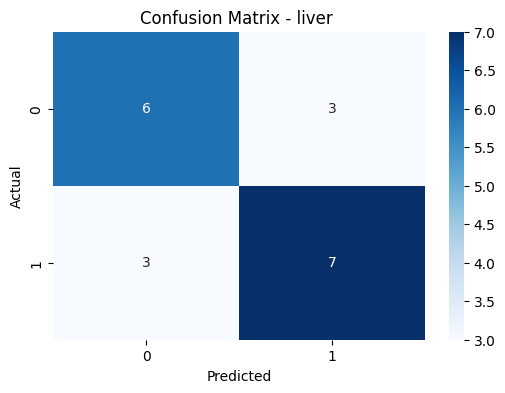

In [1]:
!pip install imblearn
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import openpyxl
df=pd.read_csv("BIOCBC.csv",encoding="cp1256",sep=";",usecols=[ 'سن بيمار',
       'جنسيت', 'محل درخواست','CBC,Diff-CBC & Diff-R.B.C',  'CBC,Diff-CBC & Diff-Hb',
         'CBC,Diff-CBC & Diff-Hct','CBC,Diff-CBC & Diff-W.B.C',"CBC,Diff-CBC & Diff-Platelet",
         "ESR 1st hr--ESR 1st hr","BS--Blood Sugar","FBS--F.B.S","BUN--B.U.N","Creatinine--Creatinine",
         "Choles--Cholesterol","TG--Triglyceride","LDL--LDL","HDL--HDL","SGOT--SGOT (AST)",
         "SGPT--SGPT(ALT)","Na--Serum Na","K--Serum K","HbA1c-Hb A1c-Hb A1c","CRP--CRP",
         "RF  به روش كمي--R.A. Factor"])
df=df.rename(columns={'سن بيمار':"age",'جنسيت':"sex",'CBC,Diff-CBC & Diff-R.B.C':"rbc",
 'محل درخواست':"ward",'CBC,Diff-CBC & Diff-Hb':"hb",'CBC,Diff-CBC & Diff-Hct':"hct",
 'CBC,Diff-CBC & Diff-W.B.C':"wbc","CBC,Diff-CBC & Diff-Platelet":"plt",
 "ESR 1st hr--ESR 1st hr":"esr","BS--Blood Sugar":"bs","FBS--F.B.S":"fbs","BUN--B.U.N":"bun",
         "Creatinine--Creatinine":"cr","Choles--Cholesterol":"chol","TG--Triglyceride":"tg",
         "LDL--LDL":"ldl","HDL--HDL":"hdl","SGOT--SGOT (AST)":"sgot","SGPT--SGPT(ALT)":"sgpt",
         "Na--Serum Na":"na","K--Serum K":"k","HbA1c-Hb A1c-Hb A1c":"a1c","CRP--CRP":"crp",
         "RF  به روش كمي--R.A. Factor":"rf"})
#pd.set_option('display.max_columns', None)
df["age"]=df["age"].str.replace("ساله","").str.replace("روزه","").str.replace(" ","")
df["age"]=pd.to_numeric(df["age"],errors="coerce")
df["ward"]=df["ward"].str.replace("بخش","").str.replace(" ","")
df["sex"]=df["sex"].str.replace("مرد","male").str.replace("زن","female")
#print(df.columns)
#print(df.head())
#print(df.shape)
#print(df.info())

diabet_cols=["fbs","sex","ward","age"]
lipid_cols=["ward","age","sex","tg","chol"]
kidney_cols=["ward","age","sex","cr","bun"]
liver_cols=["ward","age","sex","sgot","sgpt"]

print("diabet_col:",df[diabet_cols].notnull().all(axis=1).sum())
print("lipid_cols:",df[lipid_cols].notnull().all(axis=1).sum())
print("kidney_cols:",df[kidney_cols].notnull().all(axis=1).sum())
print("liver_cols:",df[liver_cols].notnull().all(axis=1).sum())

df_diabet=df[diabet_cols].dropna()
print(df_diabet.shape)
df_lipid=df[lipid_cols].dropna()
print(df_lipid.shape)
df_kidney=df[kidney_cols].dropna()
print(df_kidney.shape)
df_liver=df[liver_cols].dropna()
print(df_liver.shape)

df_diabet["fbs"]=df_diabet["fbs"].apply(lambda x: 0 if x<=120 else 1)
print(df_diabet["fbs"].value_counts())
df_lipid["tg"]=df_lipid["tg"].apply(lambda x: 0 if x<=160 else 1)
print(df_lipid["tg"].value_counts())
df_lipid["chol"]=df_lipid["chol"].apply(lambda x: 0 if x<=240 else 1)
print(df_lipid["chol"].value_counts())
df_kidney["cr"]=df_kidney["cr"].apply(lambda x: 0 if x<=1.5 else 1)
print(df_kidney["cr"].value_counts())
df_kidney["bun"]=df_kidney["bun"].apply(lambda x: 0 if x<=23 else 1)
print(df_kidney["bun"].value_counts())
df_liver["sgot"]=df_liver["sgot"].apply(lambda x: 0 if x<=40 else 1)
print(df_liver["sgot"].value_counts())
df_liver["sgpt"]=df_liver["sgpt"].apply(lambda x: 0 if x<40 else 1)
print(df_liver["sgpt"].value_counts())

df_kidney['sex'] = df_kidney['sex'].map({'male': 0, 'female': 1})

X_kidney = df_kidney[['age', 'sex']]
y_kidney = df_kidney['cr']
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_kidney, y_kidney, test_size=0.2, random_state=42)
clf_kidney = LogisticRegression(class_weight='balanced')
clf_kidney.fit(X_train_k, y_train_k)
y_pred_k = clf_kidney.predict(X_test_k)
print("Accuracy_creatinine:", accuracy_score(y_test_k, y_pred_k))
print(confusion_matrix(y_test_k, y_pred_k))
print(classification_report(y_test_k, y_pred_k))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_k, y_pred_k), annot=True,cmap='Blues')
plt.title("Confusion Matrix - Creatinine (Model 1)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

X_kidney_s = df_kidney[['age', 'sex']]
y_kidney_s = df_kidney['cr']
X_train_k_s, X_test_k_s, y_train_k_s, y_test_k_s = train_test_split(X_kidney_s,
 y_kidney_s, test_size=0.2, random_state=42)
smote=SMOTE(random_state=42)##
X_train_k_res, y_train_k_res=smote.fit_resample(X_train_k_s, y_train_k_s)##
clf_kidney = LogisticRegression(class_weight='balanced')
clf_kidney.fit(X_train_k_res, y_train_k_res)
y_pred_k_smote = clf_kidney.predict(X_test_k)
print("Accuracy_creatinine_with_smote:", accuracy_score(y_test_k, y_pred_k))
print(confusion_matrix(y_test_k, y_pred_k_smote))
print(classification_report(y_test_k_s, y_pred_k))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_k_s, y_pred_k_smote), annot=True,cmap='Blues')
plt.title("Confusion Matrix - Creatinine (Model smote)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ward_dummies=pd.get_dummies(df_kidney["ward"],prefix="ward")##
X_kidney2=pd.concat([df_kidney[["age","sex",]],ward_dummies],axis=1)##
Y_kidney2=df_kidney["cr"]
X_train_k2, X_test_k2, Y_train_k2, Y_test_k2 = train_test_split(X_kidney2,
 Y_kidney2, test_size=0.2, random_state=42)
clf_kidney2 = LogisticRegression(class_weight='balanced')
clf_kidney2.fit(X_train_k2, Y_train_k2)
Y_pred_k2 = clf_kidney2.predict(X_test_k2)
print("Accuracy_creatinine_2:", accuracy_score(Y_test_k2, Y_pred_k2))
print(confusion_matrix(Y_test_k2, Y_pred_k2))
print(classification_report(Y_test_k2, Y_pred_k2))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(Y_test_k2, Y_pred_k2), annot=True,cmap='Blues')
plt.title("Confusion Matrix - Creatinine (Model 2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

X_kidney3=pd.concat([df_kidney[["age","sex",]],ward_dummies],axis=1)##
Y_kidney3=df_kidney["bun"]
X_train_k3,X_test_k3,Y_train_k3,Y_test_k3=train_test_split(X_kidney3,
 Y_kidney3, test_size=0.2, random_state=42)
clf_kidney3 = LogisticRegression(class_weight='balanced')
clf_kidney3.fit(X_train_k3, Y_train_k3)
Y_pred_k3 = clf_kidney3.predict(X_test_k3)
print("Accuracy_bun:", accuracy_score(Y_test_k3, Y_pred_k3))
print(confusion_matrix(Y_test_k3, Y_pred_k3))
print(classification_report(Y_test_k3, Y_pred_k3))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(Y_test_k3,Y_pred_k3),annot=True,cmap='Blues')
plt.title("Confusion Matrix - bun ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

df_liver["liver"]=(df_liver["sgot"]==1) | (df_liver["sgpt"]==1)##
df_liver['liver'] = df_liver['liver'].astype(int)##
print(df_liver["liver"].value_counts())
df_liver['sex'] = df_liver['sex'].map({'male': 0, 'female': 1})
ward_dummies=pd.get_dummies(df_liver["ward"],prefix="ward")

x_liver=pd.concat([df_liver[["age","sex"]],ward_dummies],axis=1)
y_liver=df_liver["liver"]
x_train_l,x_test_l,y_train_l,y_test_l=train_test_split(x_liver
,y_liver,test_size=0.2,random_state=42)
clf_liver=LogisticRegression(class_weight="balanced")
clf_liver.fit(x_train_l,y_train_l)
y_pred_l=clf_liver.predict(x_test_l)
print("Accuracy_liver:",accuracy_score(y_test_l,y_pred_l))
print(confusion_matrix(y_test_l,y_pred_l))
print(classification_report(y_test_l,y_pred_l))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_l,y_pred_l),annot=True,cmap='Blues')
plt.title("Confusion Matrix - liver ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=17d9599a-e07d-4c50-b1b1-f0833538d301' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>